In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Назви й значення фіч анонімізовані (A1-A15), останній стовпець - таргет
# (схвалення кредиту). Пропуски у файлі позначені "?" - читаємо їх одразу як NaN.
cols = [f"A{i}" for i in range(1, 16)] + ["target"]
df = pd.read_csv("crx.data", header=None, names=cols, na_values="?")
df.shape

(690, 16)

In [3]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  target  690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [5]:
# Пропуски по колонках
df.isna().sum()[df.isna().sum() > 0]

A1     12
A2     12
A4      6
A5      6
A6      9
A7      9
A14    13
dtype: int64

In [6]:
# Пропуски є у 7 колонках (усього 37 рядків, ~5%).

In [7]:
# Розділяємо фічі на числові та категоріальні
num_cols = df.drop(columns="target").select_dtypes(include="number").columns.tolist()
cat_cols = df.drop(columns="target").select_dtypes(exclude="number").columns.tolist()
print("числові    :", num_cols)
print("категоріальні:", cat_cols)

числові    : ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
категоріальні: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


In [8]:
# 6 числових фіч і 9 категоріальних. Категоріальні доведеться перетворити на числа (дерево в sklearn, а також LogReg і kNN розуміють лише числа). A6 (14 значень) і A7 (9) мають багато категорій - при One-Hot дадуть чимало нових колонок.

In [9]:
# Кодуємо таргет: "+" (кредит схвалено) -> 1, "-" (відмова) -> 0
df["target"] = (df["target"] == "+").astype("int8")
df["target"].value_counts()

target
0    383
1    307
Name: count, dtype: int64

In [10]:
# Схвалень і відмов приблизно порівну (383 проти 307, ~55/45). Це добре: коли класів приблизно порівну, простій оцінці "скільки відповідей модель угадала правильно" можна довіряти. Але пізніше подивимось і на інші способи оцінити модель - щоб побачити повнішу картину.

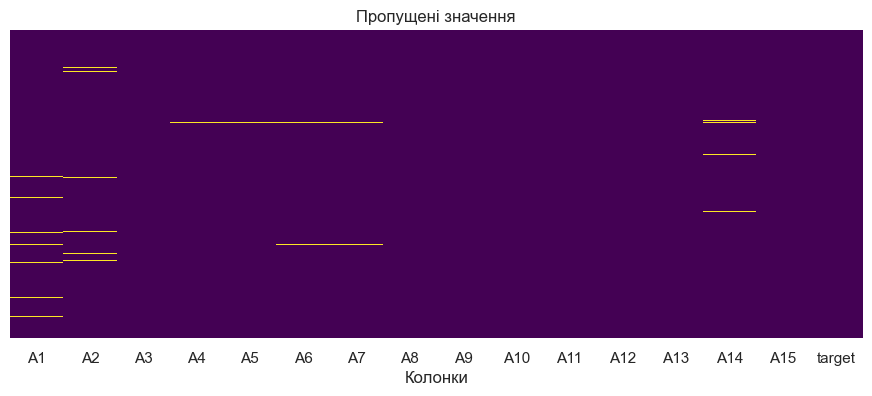

In [11]:
# Крок 2. Графічний аналіз
# Карта пропущених значень
plt.figure(figsize=(11, 4))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Пропущені значення")
plt.xlabel("Колонки")
plt.show()

In [12]:
# Пропусків небагато, вони розкидані по 7 колонках без явної системи (схоже, випадкові). Це добре - можна спокійно заповнити їх, не втрачаючи рядки.

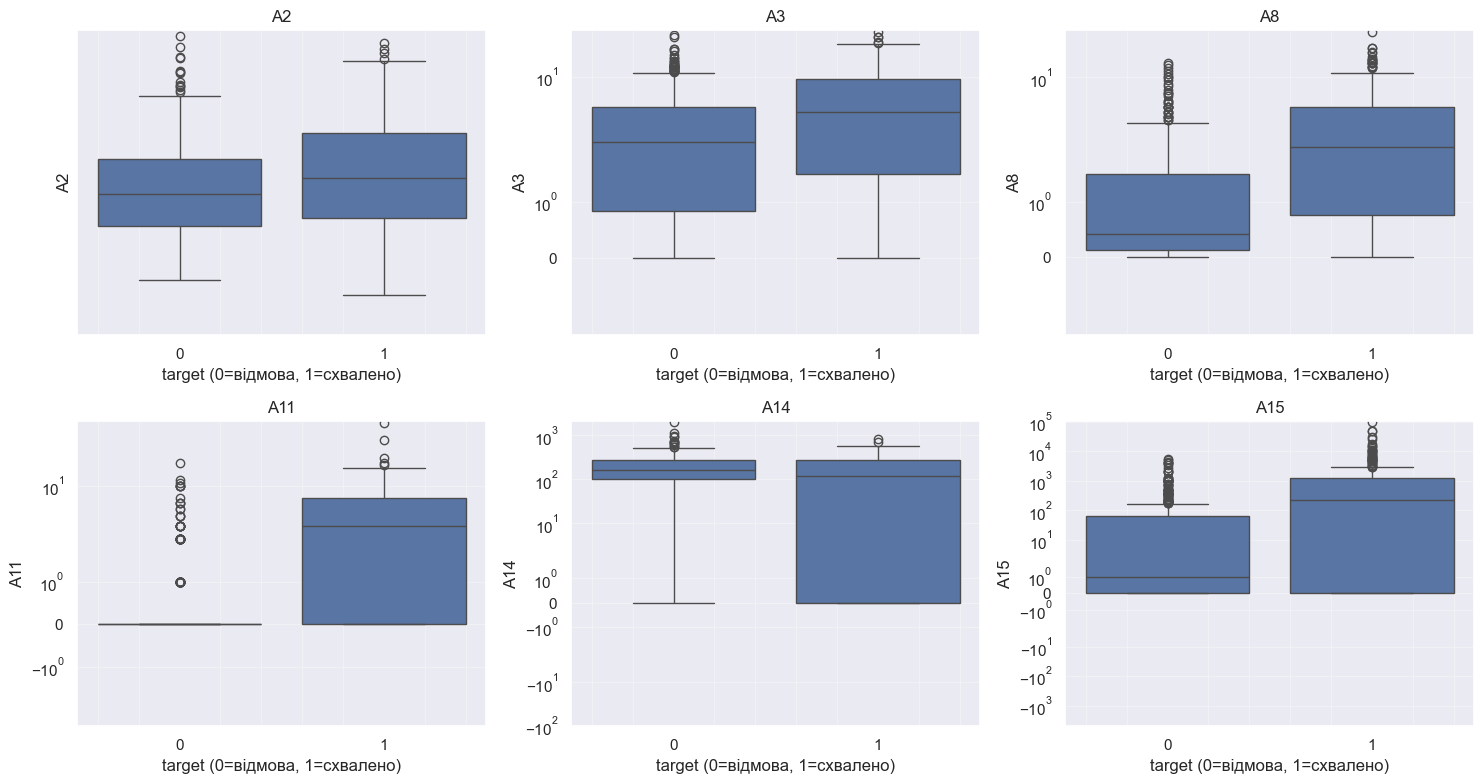

In [13]:
# Числові фічі в розрізі класів (шкала symlog - щоб було видно і "коробку", і викиди)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="target", y=col, ax=ax)
    ax.set_yscale("symlog")
    ax.set_title(col)
    ax.set_xlabel("target (0=відмова, 1=схвалено)")
plt.tight_layout()
plt.show()

In [14]:
# Тепер видно й викиди. У схвалених заявок (клас 1) вищі A11, A8 і A3 - і за типовими значеннями (коробка), і за окремими великими значеннями (великі значення A15 чи A11 майже завжди трапляються саме у схвалених). A14 трохи нижча у схвалених. Викиди тут не помилки, а реальні великі значення, тож дерево цілком може на них спиратися. Найкорисніші числові фічі - A11 і A8. (Шкала symlog логарифмічна, тому вісь стиснута: так одночасно видно і основну масу даних, і хвости.)

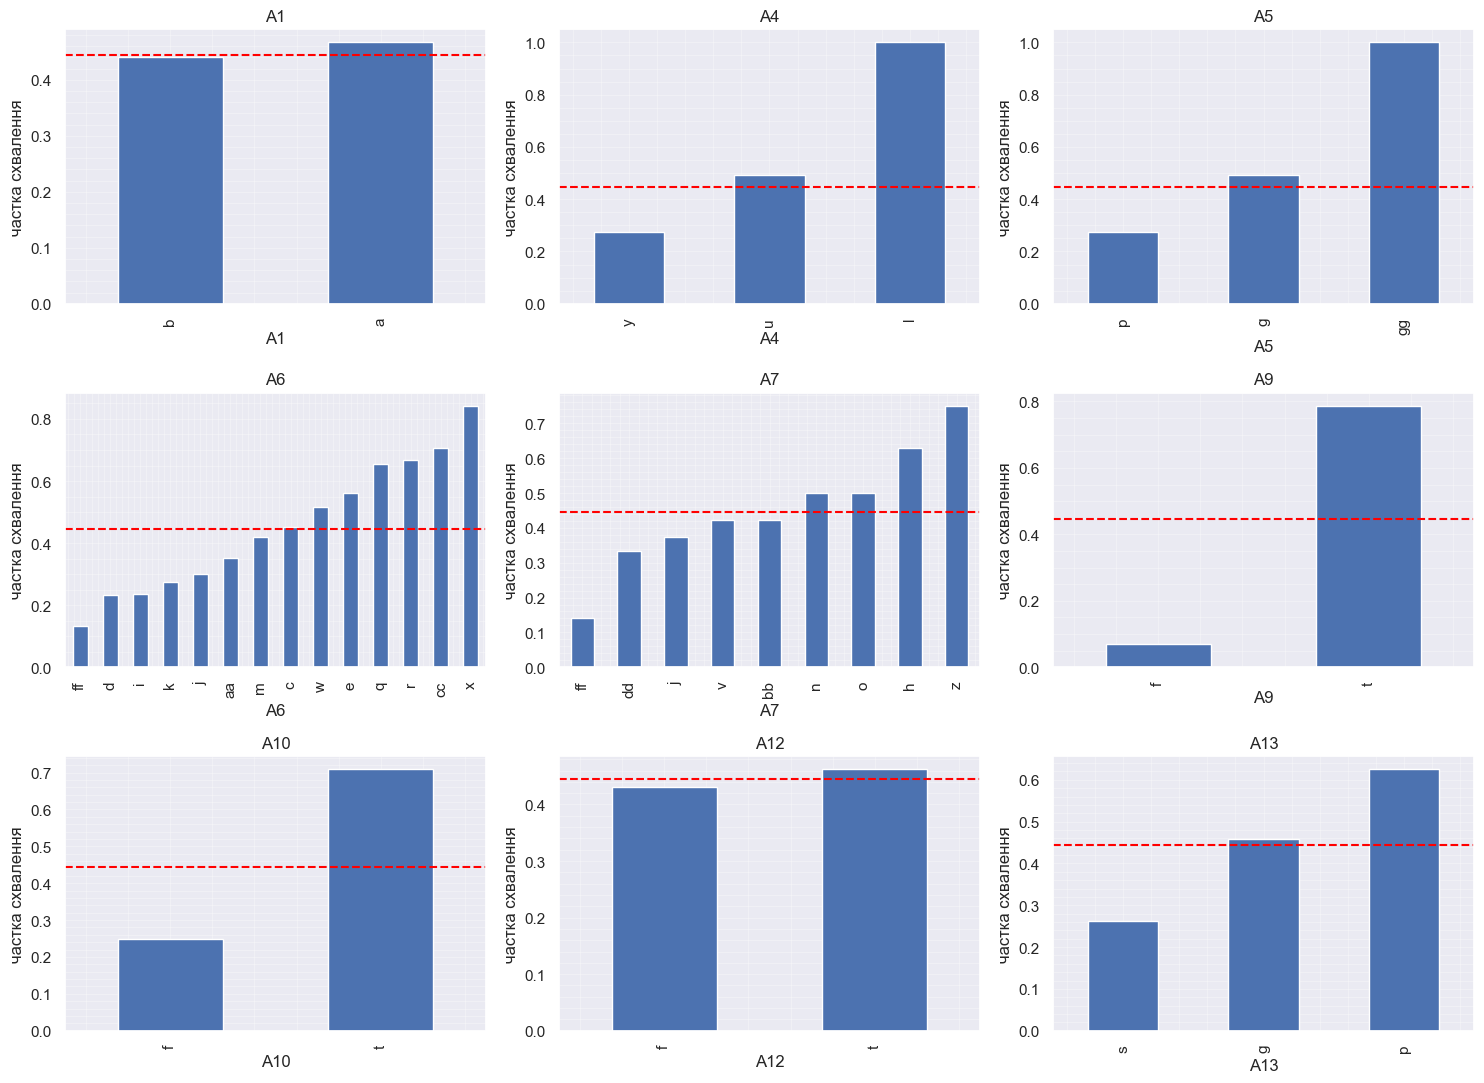

In [15]:
# Частка схвалення по кожному значенню категоріальних фіч
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
overall = df["target"].mean()
for ax, col in zip(axes.ravel(), cat_cols):
    df.groupby(col)["target"].mean().sort_values().plot(kind="bar", ax=ax)
    ax.axhline(overall, color="red", linestyle="--")  # середня частка схвалення
    ax.set_title(col)
    ax.set_ylabel("частка схвалення")
plt.tight_layout()
plt.show()

In [16]:
# Червона лінія - середня частка схвалення по всіх заявках. Чим далі стовпчики фічі від цієї лінії, тим сильніше фіча впливає на рішення. Найяскравіша - A9: одне її значення дає дуже низьку частку схвалень, а інше - дуже високу (стовпчики розлітаються в протилежні краї - майже вирішальна фіча!). Помітно впливають також A4/A5, A6, A7, A10, A13. А от у A1 і A12 стовпчики тримаються біля лінії - ці фічі майже не впливають, і модель їх, найімовірніше, проігнорує.

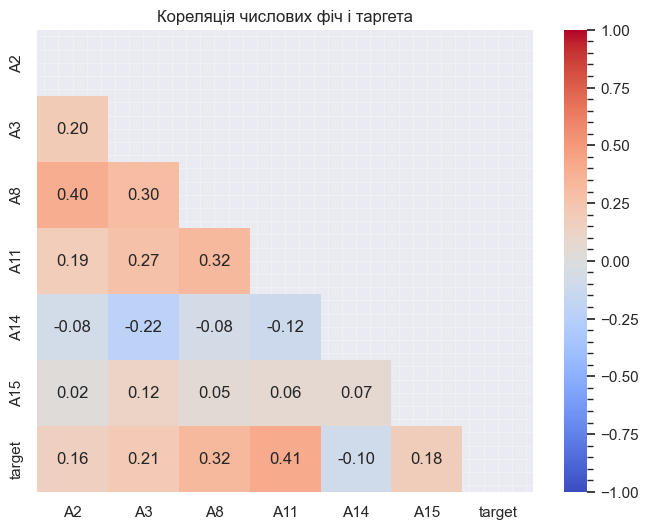

In [17]:
# Кореляція числових фіч між собою та з таргетом
plt.figure(figsize=(8, 6))
corr = df[num_cols + ["target"]].corr()
mask = np.triu(corr)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, mask=mask)
plt.title("Кореляція числових фіч і таргета")
plt.show()

In [18]:
# З таргетом найсильніше корелюють A11 (+0.41) і A8 (+0.32) - це підтверджує боксплоти. Між собою числові фічі корелюють слабко, тобто дублюючих фіч немає (для дерева це неважливо, але для LogReg і kNN - добра новина).

In [19]:
# Крок 3. Фіча-інжиніринг
# 1) A8_plus_A11 - "фінансова сила": сума двох найсильніших числових предикторів.
#    Дерево розбиває простір перпендикулярно осям, тож таку "діагональну" суму
#    воно саме не побудує - тому додаємо її вручну.
df["A8_plus_A11"] = df["A8"] + df["A11"]

# 2) A11_positive - чи є ненульовий A11 (простий і сильний бінарний прапорець)
df["A11_positive"] = (df["A11"] > 0).astype("int8")

# Додаємо нові числові фічі до списку (знадобиться далі при масштабуванні)
num_cols = num_cols + ["A8_plus_A11", "A11_positive"]
df[["A8", "A11", "A8_plus_A11", "A11_positive", "target"]].head()

,A8,A11,A8_plus_A11,A11_positive,target
0,1.25,1,2.25,1,1
1,3.04,6,9.04,1,1
2,1.50,0,1.50,0,1
3,3.75,5,8.75,1,1
4,1.71,0,1.71,0,1


In [20]:
# Перевіряємо сигнал нових фіч (кореляція з таргетом)
df[["A8_plus_A11", "A11_positive"]].corrwith(df["target"]).round(3)

A8_plus_A11     0.454
A11_positive    0.458
dtype: float64

In [21]:
# Обидві нові фічі несуть сильний сигнал: A11_positive (~0.46) і A8_plus_A11 (~0.45) корелюють з таргетом навіть сильніше за будь-яку сиру числову фічу (найкраща сира - A11, +0.41). A8_plus_A11 особливо цінна для дерева, бо це сума ("діагональ"), яку дерево саме не побудує.

In [22]:
# Крок 4. Препроцесинг
# Спочатку поділ (щоб заповнення пропусків і кодування "вчились" лише на train,
# без витоку), а вже потім - препроцесинг.
X = df[num_cols + cat_cols]
y = df["target"]

# Поділ train/val/test = 60/20/20. stratify=y - щоб зберегти баланс класів у кожній частині
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 414 | val: 138 | test: 138


In [23]:
# Дані поділено 60/20/20 так, щоб у кожній частині лишалась однакова частка схвалень і відмов (~55/45). train - для навчання, val - для порівняння моделей і підбору налаштувань, test - фінальна чесна перевірка.

In [24]:
# Препроцесор: числові -> заповнення медіаною; категоріальні -> заповнення найчастішим значенням + One-Hot
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_cols),
])

# fit лише на train; val і test тільки трансформуємо
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

# загортаємо назад у DataFrame зі збереженням назв колонок
feat_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feat_names, index=X_train.index)
X_val_prep = pd.DataFrame(X_val_prep, columns=feat_names, index=X_val.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=feat_names, index=X_test.index)

print("колонок після препроцесингу:", X_train_prep.shape[1])
X_train_prep.head()

колонок після препроцесингу: 48


,num__A2,num__A3,num__A8,num__A11,num__A14,num__A15,num__A8_plus_A11,num__A11_positive,cat__A1_a,cat__A1_b,...,cat__A7_z,cat__A9_f,cat__A9_t,cat__A10_f,cat__A10_t,cat__A12_f,cat__A12_t,cat__A13_g,cat__A13_p,cat__A13_s
505,31.33,19.500,7.000,16.0,0.0,5000.0,23.000,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
512,44.33,0.000,2.500,0.0,0.0,0.0,2.500,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
444,17.67,0.000,0.000,0.0,86.0,0.0,0.000,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
416,22.50,0.125,0.125,0.0,200.0,70.0,0.125,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
632,38.75,1.500,0.000,0.0,76.0,0.0,0.000,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [25]:
# Поділ зроблено перед препроцесингом, тож медіани (для числових) і найчастіші значення (для категоріальних) беруться лише з train - val і test "не підглядають". Числові пропуски заповнено медіаною, категоріальні - найчастішим значенням; категоріальні розгорнуто в One-Hot (кожне значення -> окрема 0/1-колонка; handle_unknown="ignore", щоб нове значення в test не зламало код). Було 17 фіч -> стало 48 колонок (8 числових + 40 one-hot).

In [26]:
# Крок 5. Базова модель - DecisionTreeClassifier з дефолтними параметрами
def evaluate(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    res = {"accuracy": accuracy_score(y, pred),
           "precision": precision_score(y, pred),
           "recall": recall_score(y, pred),
           "F1": f1_score(y, pred),
           "ROC_AUC": roc_auc_score(y, proba)}
    print(f"{name:6} acc={res['accuracy']:.3f}  prec={res['precision']:.3f}  "
          f"rec={res['recall']:.3f}  F1={res['F1']:.3f}  AUC={res['ROC_AUC']:.3f}")
    return res

# дерево не потребує масштабування, тому вчимо прямо на препроцесованих даних
tree = DecisionTreeClassifier(random_state=42).fit(X_train_prep, y_train)
evaluate(tree, X_train_prep, y_train, "train")
baseline_val = evaluate(tree, X_val_prep, y_val, "val")
print("глибина:", tree.get_depth(), "| листків:", tree.get_n_leaves())

train  acc=1.000  prec=1.000  rec=1.000  F1=1.000  AUC=1.000
val    acc=0.775  prec=0.768  rec=0.705  F1=0.735  AUC=0.768
глибина: 13 | листків: 62


In [27]:
# Цікаве спостереження: на train модель угадала все ідеально (усі метрики = 1.000), а на val помітно гірше (accuracy ~0.78). Схоже, дерево просто "запам'ятало" навчальні приклади напам'ять - воно виросло дуже глибоким (13 рівнів, 62 листки) і поділило дані мало не до кожного окремого рядка. На своїх даних це виглядає ідеально, а на нових воно плутається. Таке "зубріння" називають перенавчанням. Далі (Крок 6) спробуємо обмежити ріст дерева й подивитись, чи покращиться результат на val.

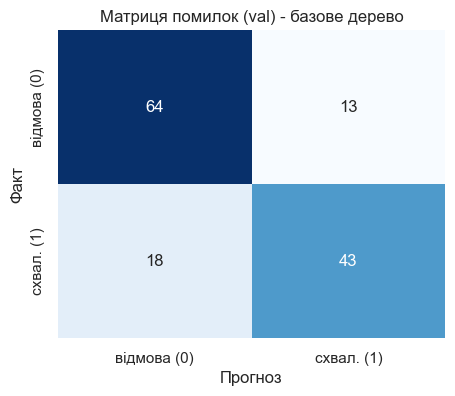

In [28]:
# Матриця помилок на val
cm = confusion_matrix(y_val, tree.predict(X_val_prep))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["відмова (0)", "схвал. (1)"],
            yticklabels=["відмова (0)", "схвал. (1)"])
plt.xlabel("Прогноз")
plt.ylabel("Факт")
plt.title("Матриця помилок (val) - базове дерево")
plt.show()

In [29]:
# По діагоналі - правильні прогнози (64 вірні відмови + 43 вірні схвалення). Поза діагоналлю - помилки: 13 разів модель сказала "схвалити", хоча насправді була відмова, і 18 разів навпаки - "відмова", хоча схвалили. Помилки приблизно порівну в обидва боки. Тому важливо дивитись не лише на загальну кількість правильних відповідей, а й на те, як саме модель помиляється в кожен бік.

In [30]:
# Крок 6. Підбір гіперпараметрів дерева (GridSearchCV, 5-fold, метрика ROC-AUC)
tree_params = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params, scoring="roc_auc", cv=5, n_jobs=-1)
tree_grid.fit(X_train_prep, y_train)

best_tree = tree_grid.best_estimator_
print("найкращі параметри:", tree_grid.best_params_)
print("cv ROC-AUC:", round(tree_grid.best_score_, 3))
print("глибина:", best_tree.get_depth(), "| листків:", best_tree.get_n_leaves())

найкращі параметри: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
cv ROC-AUC: 0.894
глибина: 3 | листків: 7


In [31]:
# Порівняння на val: базове дерево vs налаштоване
print("Базове дерево:")
evaluate(tree, X_val_prep, y_val, "val")
print("Налаштоване дерево:")
tuned_tree_val = evaluate(best_tree, X_val_prep, y_val, "val")

Базове дерево:
val    acc=0.775  prec=0.768  rec=0.705  F1=0.735  AUC=0.768
Налаштоване дерево:
val    acc=0.877  prec=0.958  rec=0.754  F1=0.844  AUC=0.948


In [32]:
# Вийшло помітно краще! Найкращим виявилось неглибоке дерево (max_depth=3, лише 7 листків замість 62). Коли ми обмежили глибину, дерево перестало "зубрити": на val усі оцінки зросли (наприклад, частка правильних відповідей - з 0.78 до 0.88). Тобто просте дерево з 3 рівнів запитань працює на нових даних набагато краще за глибоке. При цьому воно обережне: коли каже "схвалити" - майже завжди вгадує, але частину справжніх схвалень усе ж пропускає.

In [33]:
# Крок 7. Порівняння з LogisticRegression і kNN
# Обидві моделі чутливі до масштабу фіч (на відміну від дерева), тому загортаємо
# їх у Pipeline зі StandardScaler - масштабування "вчиться" всередині крос-валідації
logreg_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    {"clf__C": [0.01, 0.1, 1, 10, 100]},
    scoring="roc_auc", cv=5, n_jobs=-1)
logreg_grid.fit(X_train_prep, y_train)
best_logreg = logreg_grid.best_estimator_
print("LogReg best:", logreg_grid.best_params_)

knn_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    {"clf__n_neighbors": range(3, 30, 2), "clf__weights": ["uniform", "distance"]},
    scoring="roc_auc", cv=5, n_jobs=-1)
knn_grid.fit(X_train_prep, y_train)
best_knn = knn_grid.best_estimator_
print("kNN best:", knn_grid.best_params_)

LogReg best: {'clf__C': 0.01}
kNN best: {'clf__n_neighbors': 23, 'clf__weights': 'distance'}


In [34]:
# Зведена таблиця метрик на val для трьох моделей
models = {"DecisionTree": best_tree, "LogisticRegression": best_logreg, "kNN": best_knn}
comparison = pd.DataFrame(
    {name: evaluate(m, X_val_prep, y_val, name[:6]) for name, m in models.items()}
).T
comparison.round(3)

Decisi acc=0.877  prec=0.958  rec=0.754  F1=0.844  AUC=0.948
Logist acc=0.855  prec=0.847  rec=0.820  F1=0.833  AUC=0.929


kNN    acc=0.870  prec=0.877  rec=0.820  F1=0.847  AUC=0.910


,accuracy,precision,recall,F1,ROC_AUC
DecisionTree,0.877,0.958,0.754,0.844,0.948
LogisticRegression,0.855,0.847,0.820,0.833,0.929
kNN,0.870,0.877,0.820,0.847,0.910


In [35]:
# Усі три моделі дали близький результат (val AUC 0.91-0.95), тобто задача добре розв'язується різними підходами. Найкраще - налаштоване дерево (AUC 0.95, accuracy 0.88): воно і трохи точніше, і найзрозуміліше (правила дерева можна намалювати й прочитати). LogReg і kNN трохи позаду за AUC, зате мають рівніший баланс precision/recall (recall 0.82 проти 0.75 у дерева - тобто пропускають менше справжніх схвалень). Висновок: для цих даних дерево - хороший вибір, бо поєднує високу якість із зрозумілістю (його рішення легко пояснити).

In [36]:
# Крок 8. Фінальна оцінка найкращої моделі (дерева) на train / val / test
final_summary = pd.DataFrame({
    "train": evaluate(best_tree, X_train_prep, y_train, "train"),
    "val":   evaluate(best_tree, X_val_prep, y_val, "val"),
    "test":  evaluate(best_tree, X_test_prep, y_test, "test"),
}).T.round(3)
final_summary

train  acc=0.850  prec=0.892  rec=0.757  F1=0.819  AUC=0.928
val    acc=0.877  prec=0.958  rec=0.754  F1=0.844  AUC=0.948
test   acc=0.833  prec=0.932  rec=0.672  F1=0.781  AUC=0.959


,accuracy,precision,recall,F1,ROC_AUC
train,0.850,0.892,0.757,0.819,0.928
val,0.877,0.958,0.754,0.844,0.948
test,0.833,0.932,0.672,0.781,0.959


In [37]:
# На test дерево тримає високу якість - майже таку саму, як на val. Тобто на зовсім нових даних, яких воно не бачило, воно не просіло: перенавчання немає. Модель обережна: коли схвалює - майже завжди правильно, але частину справжніх схвалень пропускає (радше відмовить, ніж помилково схвалить). Якщо банку важливіше не прогавити хорошого клієнта, модель можна було б підкрутити саме під це.

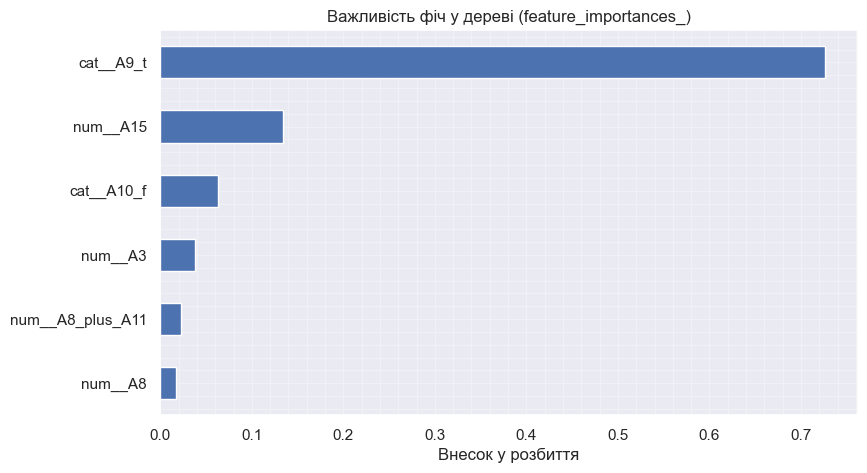

In [38]:
# Найважливіші фічі за версією самого дерева
importances = pd.Series(best_tree.feature_importances_, index=X_train_prep.columns)
importances = importances[importances > 0].sort_values()
plt.figure(figsize=(9, 5))
importances.plot(kind="barh")
plt.title("Важливість фіч у дереві (feature_importances_)")
plt.xlabel("Внесок у розбиття")
plt.show()

In [39]:
# Дерево спирається насамперед на A9 (~73% усіх розбиттів!) - це та сама фіча, яку ще на графічному аналізі (Крок 2) ми бачили як майже вирішальну (7% vs 79% схвалень). Далі йдуть A15 і A10, а наша рукотворна A8_plus_A11 теж потрапила в дерево (хай і з невеликим внеском). Марні фічі (A1, A12) дерево взагалі не використало - модель сама відібрала значуще. Тобто feature_importances_ підтвердив висновки первинного аналізу.

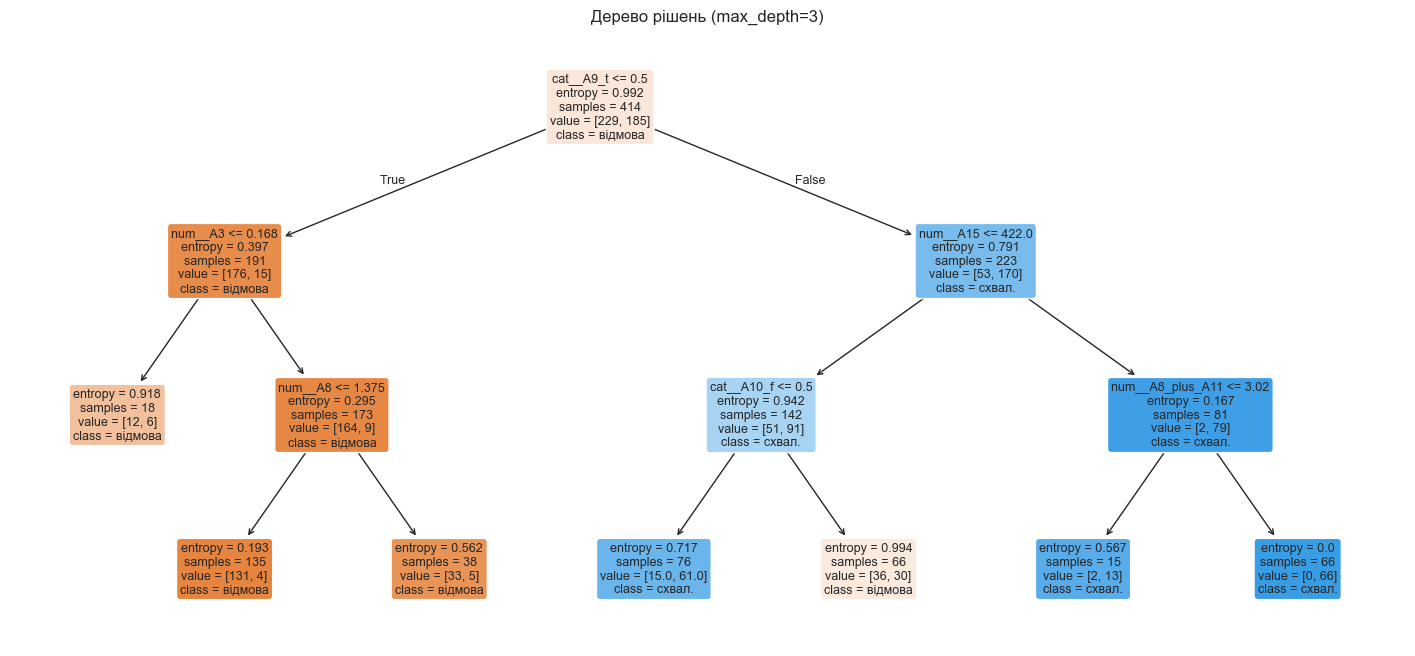

In [40]:
# Візуалізація дерева - головна перевага цієї моделі: правила видно очима
plt.figure(figsize=(18, 8))
plot_tree(best_tree, feature_names=X_train_prep.columns,
          class_names=["відмова", "схвал."], filled=True, rounded=True, fontsize=9)
plt.title("Дерево рішень (max_depth=3)")
plt.show()

In [41]:
# Усе дерево - лише 3 рівні запитань, і його можна прочитати як інструкцію. Перше (найголовніше) запитання - по фічі A9, далі - уточнення по інших. У кожному листку видно, скільки заявок туди потрапило і який клас призначається. Саме ця прозорість - головна перевага дерев над LogReg/kNN: банк може пояснити клієнту, ЧОМУ прийнято те чи інше рішення.

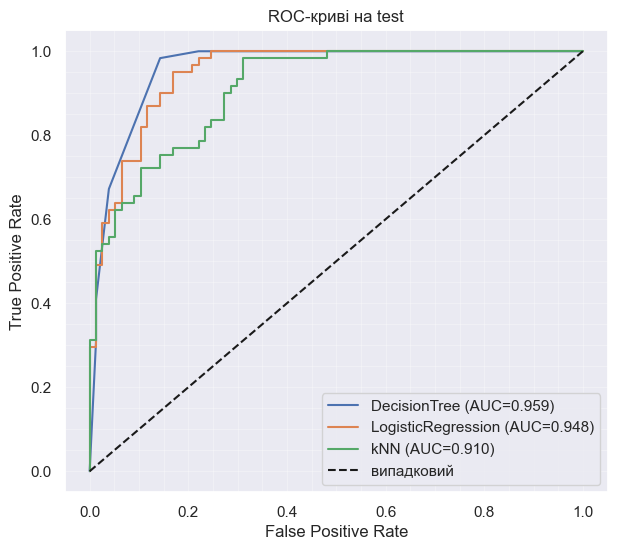

In [42]:
# ROC-криві трьох моделей на test
plt.figure(figsize=(7, 6))
for name, m in models.items():
    proba = m.predict_proba(X_test_prep)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="випадковий")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-криві на test")
plt.legend()
plt.show()

In [43]:
# Усі три криві високо над діагоналлю (діагональ - це випадкове вгадування). Чим ближче крива до лівого верхнього кута, тим краща модель. Криві дерева, LogReg і kNN ідуть майже разом, дерево - трохи вище за інші. Тобто всі три моделі добре відрізняють хороші заявки від поганих, а дерево - трохи найкраще.

In [44]:
# ПІДСУМОК: ми навчили дерево рішень схвалювати/відхиляти кредитні заявки. Ключові етапи: заповнили пропуски, закодували категоріальні фічі (One-Hot), додали 2 нові фічі, поділили дані 60/20/20 і підібрали параметри через GridSearchCV. Головний урок про дерева: без обмежень воно "зазубрює" train (усі метрики = 1.0, але слабко на нових даних), а неглибоке дерево (max_depth=3) працює набагато краще (test AUC 0.96). Дерево трохи випередило LogisticRegression і kNN за якістю, а головне - воно єдине, чиє рішення можна наочно пояснити. Найважливіша ознака - A9.